# Biscayne Runtime Benckmark Plots
# author: roh@sgmco.cl

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
import matplotlib.font_manager as fm
import seaborn as sns
from datetime import datetime

print(f'Pandas version: {pd.__version__}')
print(f'Matplotlib version: {mpl.__version__}')
print(f'Numpy version: {np.__version__}')
print ('Current Enviroment: '+os.environ['CONDA_DEFAULT_ENV'])

# Font configuration
available_fonts = [f.name for f in fm.fontManager.ttflist]

if 'Arial' in available_fonts:
    font = {'family': 'Arial', 'weight': 'normal'}
    print("Arial Font available")
    plt.rcParams['font.family'] = 'Arial'
else:
    print("Arial not available, using default font")
    font = {'family': 'sans-serif', 'weight': 'normal'}
    
mpl.rc('font', **font)

cwd = os.getcwd()
print(f'Current Working Dir: {cwd}')

Pandas version: 2.2.3
Matplotlib version: 3.10.8
Numpy version: 2.2.5
Current Enviroment: esi_py25_adv2_final
Arial Font available
Current Working Dir: /Users/roh.sgm/Documents/GitHub_Projects/ARM_Benchmark_Public/ARM_Benchmark_Public/Scripts/Post-Proc


# Data Import

In [2]:
# Read data from file
data_path = os.path.join(cwd, '..', '..','Runtimes', 'ByscayneMode_Benchmarks.xlsx')

# Read the full sheet to extract metadata and data
df_full = pd.read_excel(data_path, sheet_name='Runtimes', header=None)

# Read additional metadata from Authors sheet
extra_meta_data = pd.read_excel(data_path, sheet_name='Authors')

# Extract metadata from first 3 rows (row indices 0, 1, 2)
metadata_rows = df_full.iloc[:3, :]

# Row 3 (index 3) contains column headers/labels
headers = df_full.iloc[3, :].tolist()

# Extract runtime data starting from row 4 (index 4)
# Row 4 = 1 agent, Row 5 = 2 agents, ..., Row 19 = 16 agents
data = df_full.iloc[4:, :].reset_index(drop=True)

# Set column names from headers
data.columns = headers

# Create meaningful labels by combining metadata from the 3 rows
# Assuming columns represent different tests/configurations
test_labels = []
for col_idx in range(1, len(df_full.columns)):  # Skip first column (assumed to be agent count)
    meta_info = [
        str(metadata_rows.iloc[0, col_idx]),  # Row 0 metadata
        str(metadata_rows.iloc[1, col_idx]),  # Row 1 metadata
        str(metadata_rows.iloc[2, col_idx])   # Row 2 metadata
    ]
    # Combine metadata with newlines or other separator, filtering out 'nan'
    label = '\n'.join([m for m in meta_info if m != 'nan' and m.strip()])
    test_labels.append(label)

print(f"📊 Loaded {len(test_labels)} test configurations")
print(f"📈 Runtime data shape: {data.shape}")
print(f"\nTest Labels:")
for i, label in enumerate(test_labels, 1):
    print(f"  Test {i}: {label.replace(chr(10), ' | ')}")  # Replace newlines with | for display

display("Extra Metadata (Authors sheet):", extra_meta_data.head())

display("Metadata (first 3 rows):", metadata_rows)
display("Runtime Data (from row 3 onwards):", data)

📊 Loaded 17 test configurations
📈 Runtime data shape: (16, 18)

Test Labels:
  Test 1: i7-10750H  | Legion7i | (12c-2.7GHz)
  Test 2: i7-13700KF | SLG | (16c-5.4GHz)
  Test 3: i7-14700 | SA-Model5 | (20c-5.3 GHz)
  Test 4: i9-9980HK  | Dev | (8c-2.3 GHz)
  Test 5: i9-14900KF | XW Legion T7 | (24c-3.2 MHz)
  Test 6: Xeon E-2288G | DA | (8c-3.7GHz)
  Test 7: M1 | SGM001 | (8c-3.2 GHz)
  Test 8: M2 | SGM005 | (8c-3.49 GHz)
  Test 9: M2 Pro  | WorkM2 | (12c-3.48GHz)
  Test 10: M3 Max  | WorkM3 | (16c-4.05 GHz)
  Test 11: M4  | SGM023 | (10c-4.51 GHz)
  Test 12: M5  | WorkM5 | (10c-4.61GHz)
  Test 13: Ryzen 7 8845HS | Beelink | (8c-5.1 GHz)
  Test 14: AMD Ryzen 7 2700  | DA | (9 cores 4Ghz, OC)
  Test 15: Ryzen 9 5950x | KOP | (16c-4.9 GHz)
  Test 16: Ryzen Threadripper 3990X  | ESI | (64c-2.9Ghz)
  Test 17: M5 | WorkM5 | (10c-4.61GHz)


'Extra Metadata (Authors sheet):'

,#,Author,Date,OS,CPU Type,Computer,CPU Cores-Speed,Architechture,Exe Architecture,Manufacturer,Computer type,Notes
0,Test1,roh@sgmco.cl,2023-01-01,macOS,i7-10750H,Legion 7i,(12c-2.7GHz),x86,x86 (ifort),Intel,Gaming Laptop,NaN
1,Test2,salvador.lopez.gutierrez@gmail.com,2025-11-01,Win11,i7-13700KF,SLG,(16c-5.4GHz),x86,x86 (ifort),Intel,Desktop,NaN
2,Test3,darce@elmontgomery.cl,2025-08-01,Win11,i7-14700,SA-Model5,(20c-5.3 GHz),x86,x86 (ifort),Intel,Desktop,NaN
3,Test4,roh@sgmco.cl,2023-01-01,macOS,i9-9980HK,Dev,(8c-2.3 GHz),x86,x86 (ifort),Intel,MacBook Pro Laptop,NaN
4,Test5,xiaomin.wang@slrconsulting.com,2025-10-01,Win11,i9-14900KF,Legion T7,(24c-3.2 MHz),x86,x86 (ifort),Intel,Gaming Laptop,NaN


'Metadata (first 3 rows):'

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
0,CPU Type,i7-10750H,i7-13700KF,i7-14700,i9-9980HK,i9-14900KF,Xeon E-2288G,M1,M2,M2 Pro,M3 Max,M4,M5,Ryzen 7 8845HS,AMD Ryzen 7 2700,Ryzen 9 5950x,Ryzen Threadripper 3990X,M5
1,Computer,Legion7i,SLG,SA-Model5,Dev,XW Legion T7,DA,SGM001,SGM005,WorkM2,WorkM3,SGM023,WorkM5,Beelink,DA,KOP,ESI,WorkM5
2,CPU Cores,(12c-2.7GHz),(16c-5.4GHz),(20c-5.3 GHz),(8c-2.3 GHz),(24c-3.2 MHz),(8c-3.7GHz),(8c-3.2 GHz),(8c-3.49 GHz),(12c-3.48GHz),(16c-4.05 GHz),(10c-4.51 GHz),(10c-4.61GHz),(8c-5.1 GHz),"(9 cores 4Ghz, OC)",(16c-4.9 GHz),(64c-2.9Ghz),(10c-4.61GHz)


'Runtime Data (from row 3 onwards):'

,Agent Number,Test1,Test2,Test3,Test4,Test5,Test6,Test7,Test8,Test9,Test10,Test11,Test12,Test13,Test14,Test15,Test16,Test17
0,1,8.17,4.66,8.9,8.12,6.74,7.87,8.32,5.98,6.11,5.1,4.78,4.52,5.3,8.53,5.63,6.68,3.478
1,2,9.52,5.19,9.1,9.38,7.17,8.92,8.73,6.43,6.25,5.29,5.15,4.74,5.35,9.73,6.41,7,3.7012
2,3,12.6,5.61,9.89,11.07,7.44,10.8,9.27,6.95,6.4,5.55,5.36,5.02,5.88,10.71,7.76,7.17,3.9802
3,4,14.82,6.13,11.91,13.97,7.87,13.56,9.47,7.35,6.48,5.67,5.64,5.35,6.67,12.86,9.99,7.32,4.3041
4,5,18,6.67,12.69,17.58,8.53,15.79,10.78,8.4,6.75,5.82,6.21,5.83,7.62,14.65,12.91,7.38,4.636
5,6,21.23,7.29,15.07,21,9.26,NaN,11.82,9.23,6.9,5.81,6.76,6.28,9.17,17.47,15.77,7.58,5.016
6,7,24.48,7.95,15.74,24.9,10.15,24.54,13.27,10.47,7.15,5.85,7.33,6.85,10.92,19.9,18.99,7.83,5.4074
7,8,27.87,8.91,18.1,27.77,11.38,27.48,14.52,11.33,7.35,6.08,7.89,7.31,12.27,23.73,22.14,8.18,5.6641
8,9,31.13,10.21,19.43,31.43,12.62,NaN,16.32,12.75,7.81,6.26,8.58,7.85,13.5,27.57,18.99,8.55,6.2495
9,10,34.5,11.38,21.34,36.55,13.94,NaN,18.13,14.13,8.24,6.75,9.34,8.36,15,29.96,21.38,8.95,6.8451


# Heatmap Plot

🖥️ Tests selected: 17 out of 17
  Selected tests:
   - Intel i7-10750H  | Legion7i (12c-2.7GHz)
   - Intel i7-13700KF | SLG (16c-5.4GHz)
   - Intel i7-14700 | SA-Model5 (20c-5.3 GHz)
   - Intel i9-9980HK  | Dev (8c-2.3 GHz)
   - Intel i9-14900KF | XW Legion T7 (24c-3.2 MHz)
   - Intel Xeon E-2288G | DA (8c-3.7GHz)
   - Apple M1 | SGM001 (8c-3.2 GHz)
   - Apple M2 | SGM005 (8c-3.49 GHz)
   - Apple M2 Pro  | WorkM2 (12c-3.48GHz)
   - Apple M3 Max  | WorkM3 (16c-4.05 GHz)
   - Apple M4  | SGM023 (10c-4.51 GHz)
   - Apple M5  | WorkM5 (10c-4.61GHz)
   - AMD Ryzen 7 8845HS | Beelink (8c-5.1 GHz)
   - AMD AMD Ryzen 7 2700  | DA (9 cores 4Ghz, OC)
   - AMD Ryzen 9 5950x | KOP (16c-4.9 GHz)
   - AMD Ryzen Threadripper 3990X  | ESI (64c-2.9Ghz)
   - M5 | WorkM5 (10c-4.61GHz)

📊 Heatmap DataFrame shape: (17, 16)
   Rows (tests): 17
   Columns (agents): 16


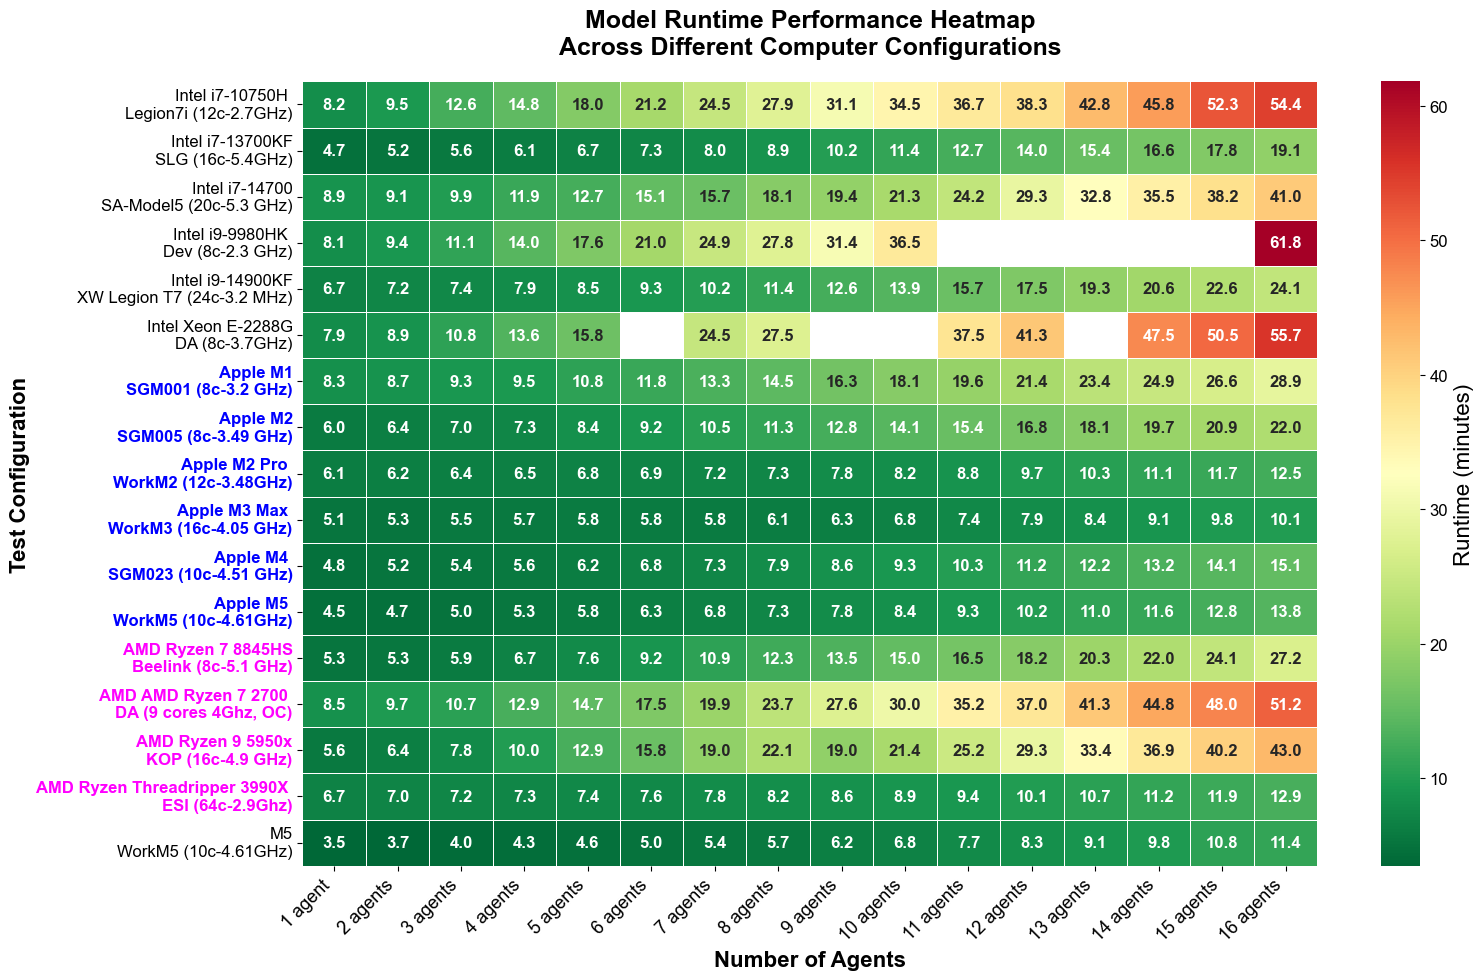


✅ Heatmap saved: /Users/roh.sgm/Documents/GitHub_Projects/ARM_Benchmark_Public/ARM_Benchmark_Public/Scripts/Post-Proc/Outputs/runtime_performance_heatmap_all_(2026-04-17_115556).png
📊 Heatmap shows runtime performance for 17 test configurations across 16 agent counts

🏆 Performance Rankings (average runtime across all agents):
   1. M5 | WorkM5 (10c-4.61GHz): 6.66 min avg | Min: 3.48 | Max: 11.37
   2. Apple M3 Max  | WorkM3 (16c-4.05 GHz): 6.93 min avg | Min: 5.10 | Max: 10.05
   3. Apple M5  | WorkM5 (10c-4.61GHz): 8.17 min avg | Min: 4.52 | Max: 13.82
   4. Apple M2 Pro  | WorkM2 (12c-3.48GHz): 8.35 min avg | Min: 6.11 | Max: 12.50
   5. AMD Ryzen Threadripper 3990X  | ESI (64c-2.9Ghz): 8.93 min avg | Min: 6.68 | Max: 12.93
   6. Apple M4  | SGM023 (10c-4.51 GHz): 8.94 min avg | Min: 4.78 | Max: 15.06
   7. Intel i7-13700KF | SLG (16c-5.4GHz): 10.60 min avg | Min: 4.66 | Max: 19.08
   8. Apple M2 | SGM005 (8c-3.49 GHz): 12.88 min avg | Min: 5.98 | Max: 21.98
   9. Intel i9-14900KF 

✅ Statistics table (PNG) saved: /Users/roh.sgm/Documents/GitHub_Projects/ARM_Benchmark_Public/ARM_Benchmark_Public/Scripts/Post-Proc/Outputs/runtime_statistics_all_(2026-04-17_115556).png


In [3]:
# ===============================================
# Heatmap Plotting Function
# ===============================================

def plot_runtime_heatmap(data, metadata_rows, config_plot, extra_meta_data=None):
    """
    Create a runtime performance heatmap.
    
    Parameters:
    -----------
    data : DataFrame
        Runtime data with computers in rows and tests in columns
    metadata_rows : DataFrame
        First 3 rows containing test metadata
    config_plot : dict
        Configuration dictionary with options:
        - 'computer_filter': str or list - 'all', 'intel', 'amd', 'apple', or list of specific names
        - 'output_folder': str - path to save output images
        - 'figsize': tuple - figure size (default: (16, 10))
        - 'cmap': str - colormap name (default: 'viridis')
        - 'dpi': int - resolution for saving (default: 300)
        - 'title': str - plot title (optional)
    extra_meta_data : DataFrame, optional
        Additional metadata including Manufacturer information
    
    Returns:
    --------
    df_heatmap : DataFrame
        The heatmap data for further analysis
    """
    
    current_time = datetime.now().strftime("%Y-%m-%d_%H%M%S")
    
    # Extract configuration
    computer_filter = config_plot.get('computer_filter', 'all')
    output_folder = config_plot.get('output_folder', os.path.join(cwd, '..', 'Output'))
    figsize = config_plot.get('figsize', (16, 10))
    cmap = config_plot.get('cmap', 'viridis')
    dpi = config_plot.get('dpi', 300)
    custom_title = config_plot.get('title', None)
    
    # Create output directory if it doesn't exist
    os.makedirs(output_folder, exist_ok=True)
    
    # Data structure in Excel:
    # - Columns 1+ represent different test configurations (computers)
    # - Rows (after row 3) represent different agent counts (1, 2, ..., 16)
    # - So we need to transpose the data to get: rows=tests, columns=agents
    
    # Create test labels from metadata columns (each column = one test)
    # Format: Manufacturer + CPU on line 1, Model + specs on line 2
    test_labels = []
    for col_idx in range(1, len(metadata_rows.columns)):
        meta_info = [
            str(metadata_rows.iloc[0, col_idx]),  # Row 0: CPU model
            str(metadata_rows.iloc[1, col_idx]),  # Row 1: Computer name/model
            str(metadata_rows.iloc[2, col_idx])   # Row 2: Specs
        ]
        # Filter out 'nan' values
        valid_meta = [m for m in meta_info if m != 'nan' and m.strip()]
        
        if len(valid_meta) >= 3:
            cpu = valid_meta[0]
            
            # Get manufacturer from extra_meta_data if available
            manufacturer = ''
            if extra_meta_data is not None and 'Manufacturer' in extra_meta_data.columns:
                # Column index corresponds to test index (col_idx - 1 since we skip column 0)
                test_idx = col_idx - 1
                if test_idx < len(extra_meta_data):
                    mfr = extra_meta_data.iloc[test_idx]['Manufacturer']
                    if pd.notna(mfr) and str(mfr).strip() and str(mfr).lower() != 'nan':
                        manufacturer = f"{str(mfr).strip()} "
            
            # First line: Manufacturer + CPU
            # Second line: Model + specs combined
            label = f"{manufacturer}{cpu}\n{valid_meta[1]} {valid_meta[2]}"
        elif len(valid_meta) == 2:
            label = f"{valid_meta[0]}\n{valid_meta[1]}"
        elif len(valid_meta) == 1:
            label = valid_meta[0]
        else:
            label = ""
        
        test_labels.append(label)
    
    # Get all test names for filtering (use first line of each label)
    all_test_names = [label.split('\n')[0] if '\n' in label else label for label in test_labels]
    
    # Apply computer filter to determine which tests to include
    if computer_filter == 'all':
        tests_to_plot_indices = list(range(len(test_labels)))
    elif computer_filter.lower() == 'intel':
        tests_to_plot_indices = [i for i, name in enumerate(all_test_names) if 'intel' in name.lower() or 'xeon' in name.lower()]
    elif computer_filter.lower() == 'amd':
        tests_to_plot_indices = [i for i, name in enumerate(all_test_names) if 'amd' in name.lower() or 'ryzen' in name.lower() or 'threadripper' in name.lower()]
    elif computer_filter.lower() == 'apple':
        tests_to_plot_indices = [i for i, name in enumerate(all_test_names) if 'apple' in name.lower() or 'm1' in name.lower() or 'm2' in name.lower() or 'm3' in name.lower() or 'm4' in name.lower()]
    elif isinstance(computer_filter, list):
        # Filter by matching test labels
        tests_to_plot_indices = [i for i, label in enumerate(test_labels) if any(filter_name in label for filter_name in computer_filter)]
    else:
        tests_to_plot_indices = list(range(len(test_labels)))
        print(f"⚠️ Unknown filter '{computer_filter}', using all tests")
    
    print(f"🖥️ Tests selected: {len(tests_to_plot_indices)} out of {len(test_labels)}")
    
    # Build data matrix - each row is a test, each column is an agent count
    # Data structure: data has agents in rows (row 0 = 1 agent, row 1 = 2 agents, etc.)
    #                 and tests in columns (col 1 = test 1, col 2 = test 2, etc.)
    # Column 0 in data typically contains agent count labels, not actual test data
    
    # Determine the number of agents (rows with data)
    # We expect 16 agents, but let's verify from the data
    n_agent_rows = min(data.shape[0], 16)  # Limit to 16 agents max
    
    data_matrix = []
    test_labels_filtered = []
    
    for test_idx in tests_to_plot_indices:
        # Column index in data is test_idx + 1 (since column 0 contains agent labels)
        col_idx = test_idx + 1
        
        if col_idx >= data.shape[1]:
            print(f"⚠️ Warning: Column index {col_idx} out of bounds for test {test_idx}")
            continue
        
        # Get runtime data for this test - only read the first n_agent_rows
        runtime_column = data.iloc[:n_agent_rows, col_idx].values
        
        # Convert to numeric, handling any non-numeric values
        numeric_row = []
        for val in runtime_column:
            try:
                if pd.isna(val) or val == 'n/a' or (isinstance(val, str) and val.lower() in ['na', 'n/a', 'nan', 'none']):
                    numeric_row.append(np.nan)
                else:
                    numeric_row.append(float(val))
            except (ValueError, TypeError):
                numeric_row.append(np.nan)
        
        data_matrix.append(numeric_row)
        test_labels_filtered.append(test_labels[test_idx])
        
    print(f"  Selected tests:")
    for label in test_labels_filtered:
        print(f"   - {label.replace(chr(10), ' | ')}")
    
    # Create agent labels for X-axis
    n_agents = len(data_matrix[0]) if data_matrix else 0
    agents = [f"{i} agent{'s' if i > 1 else ''}" for i in range(1, n_agents + 1)]
    
    # Create DataFrame for heatmap: rows=test labels, columns=agents
    df_heatmap = pd.DataFrame(data_matrix, index=test_labels_filtered, columns=agents)
    
    print(f"\n📊 Heatmap DataFrame shape: {df_heatmap.shape}")
    print(f"   Rows (tests): {df_heatmap.shape[0]}")
    print(f"   Columns (agents): {df_heatmap.shape[1]}")
    
    # Set plot style with smaller y-axis label font
    plt.rcParams.update({
        'font.family': 'Arial',
        'font.size': 13,
        'axes.titlesize': 22,
        'axes.labelsize': 16,
        'xtick.labelsize': 13,
        'ytick.labelsize': 12,  # Smaller font for y-axis labels to fit better
    })
    
    # Create heatmap
    fig, ax = plt.subplots(figsize=figsize, facecolor='white')
    
    # Create the heatmap
    heatmap = sns.heatmap(df_heatmap, 
                         annot=True, 
                         fmt='.1f', 
                         cmap=cmap,
                         cbar_kws={'label': 'Runtime (minutes)'},
                         ax=ax,
                         linewidths=0.5,
                         linecolor='white',
                         annot_kws={'size': 12, 'weight': 'bold'})
    
    # Customize the plot
    filter_text = computer_filter.upper() if isinstance(computer_filter, str) else 'SELECTED'
    if custom_title:
        ax.set_title(custom_title, fontsize=18, fontweight='bold', pad=20)
    else:
        ax.set_title(f'Model Runtime Performance Heatmap\nAcross Different Computer Configurations', 
                    fontsize=18, fontweight='bold', pad=20)
    
    ax.set_xlabel('Number of Agents', fontsize=16, fontweight='bold')
    ax.set_ylabel('Test Configuration', fontsize=16, fontweight='bold')
    
    # Rotate x-axis labels for better readability
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    
    # Color Y-axis labels based on manufacturer
    yticklabels = ax.get_yticklabels()
    for label in yticklabels:
        label_text = label.get_text()
        # Check if label starts with Apple or AMD (case-insensitive)
        if label_text.lower().startswith('apple'):
            label.set_color('blue')
            label.set_weight('bold')
        elif label_text.lower().startswith('amd'):
            label.set_color('magenta')
            label.set_weight('bold')
    
    # Adjust layout
    plt.tight_layout()
    
    # Save the plot
    os.makedirs(output_folder, exist_ok=True)
    heatmap_path = os.path.join(output_folder, f"runtime_performance_heatmap_{filter_text.lower()}_({current_time}).png")
    plt.savefig(heatmap_path, dpi=dpi, bbox_inches='tight', facecolor='white')
    
    plt.show()
    
    print(f"\n✅ Heatmap saved: {heatmap_path}")
    print(f"📊 Heatmap shows runtime performance for {len(test_labels_filtered)} test configurations across {len(agents)} agent counts")
    
    # Print performance summary with min, mean, and max
    print("\n🏆 Performance Rankings (average runtime across all agents):")
    avg_runtimes = df_heatmap.mean(axis=1, skipna=True).sort_values()
    for i, (test, avg_time) in enumerate(avg_runtimes.items(), 1):
        test_short = test.replace('\n', ' | ')[:80] + '...' if len(test.replace('\n', ' | ')) > 80 else test.replace('\n', ' | ')
        min_time = df_heatmap.loc[test].min()
        max_time = df_heatmap.loc[test].max()
        print(f"  {i:2d}. {test_short}: {avg_time:.2f} min avg | Min: {min_time:.2f} | Max: {max_time:.2f}")
    
    # Create comprehensive statistics table
    stats_data = []
    for test in df_heatmap.index:
        test_short = test.replace('\n', ' ')
        stats_data.append({
            'Computer': test_short,
            'Min (min)': df_heatmap.loc[test].min(),
            'Mean (min)': df_heatmap.loc[test].mean(),
            'Max (min)': df_heatmap.loc[test].max(),
            'Std Dev (min)': df_heatmap.loc[test].std()
        })
    
    # Create DataFrame and sort by mean runtime
    stats_df = pd.DataFrame(stats_data).sort_values('Mean (min)')
    stats_df.insert(0, 'Rank', range(1, len(stats_df) + 1))
    
    # Print formatted statistics table
    print("\n" + "="*120)
    print("📊 RUNTIME PERFORMANCE STATISTICS SUMMARY")
    print("="*120)
    print(f"{'Rank':<6} {'Computer':<45} {'Min':<12} {'Mean':<12} {'Max':<12} {'Std Dev':<12}")
    print("-"*120)
    for _, row in stats_df.iterrows():
        comp_name = row['Computer'][:43] + '..' if len(row['Computer']) > 45 else row['Computer']
        print(f"{int(row['Rank']):<6} {comp_name:<45} {row['Min (min)']:>10.2f}   {row['Mean (min)']:>10.2f}   {row['Max (min)']:>10.2f}   {row['Std Dev (min)']:>10.2f}")
    print("="*120)
    
    # Save statistics table as CSV
    stats_csv_path = os.path.join(output_folder, f"runtime_statistics_{filter_text.lower()}_({current_time}).csv")
    stats_df.to_csv(stats_csv_path, index=False, float_format='%.2f')
    print(f"\n✅ Statistics table saved: {stats_csv_path}")
    
    # Create PNG table with nice formatting
    fig_table, ax_table = plt.subplots(figsize=(14, len(stats_df) * 0.5 + 1.5), facecolor='white')
    ax_table.axis('off')
    
    # Prepare table data with formatted numbers
    table_data = []
    for _, row in stats_df.iterrows():
        comp_name = row['Computer'][:60] + '...' if len(row['Computer']) > 60 else row['Computer']
        table_data.append([
            f"{int(row['Rank'])}",
            comp_name,
            f"{row['Min (min)']:.2f}",
            f"{row['Mean (min)']:.2f}",
            f"{row['Max (min)']:.2f}",
            f"{row['Std Dev (min)']:.2f}"
        ])
    
    # Create table with tighter column widths
    table = ax_table.table(cellText=table_data,
                          colLabels=['Rank', 'Computer', 'Min (min)', 'Mean (min)', 'Max (min)', 'Std Dev (min)'],
                          cellLoc='center',  # Default center alignment
                          loc='center',
                          colWidths=[0.05, 0.50, 0.09, 0.09, 0.09, 0.09])
    
    # Style the table
    table.auto_set_font_size(False)
    table.set_fontsize(12)  # Increased from 10
    table.scale(1, 2.2)
    
    # Header styling - modern blue gradient
    header_color = '#2E86AB'
    for i in range(len(stats_df.columns)):
        cell = table[(0, i)]
        cell.set_facecolor(header_color)
        cell.set_text_props(weight='bold', color='white', fontsize=13, ha='center')  # Increased from 11, center aligned
        cell.set_edgecolor('white')
        cell.set_linewidth(1.5)
    
    # Row styling with alternating colors
    for i in range(len(table_data)):
        row_num = i + 1
        
        # Alternate row colors for better readability
        if i % 2 == 0:
            row_color = '#F5F5F5'
        else:
            row_color = 'white'
        
        # Highlight top 3 performers with gradient
        if i == 0:  # Best performer
            row_color = '#D4EDDA'  # Light green
        elif i == 1:  # Second best
            row_color = '#E7F3E7'  # Lighter green
        elif i == 2:  # Third best
            row_color = '#F0F8F0'  # Very light green
        
        for j in range(len(stats_df.columns)):
            cell = table[(row_num, j)]
            cell.set_facecolor(row_color)
            cell.set_edgecolor('#DDDDDD')
            cell.set_linewidth(0.8)
            
            # Set alignment based on column
            if j == 1:
                # Computer name - left aligned
                cell.set_text_props(ha='left', fontsize=12)
            else:
                # All other columns - center aligned
                cell.set_text_props(ha='center', fontsize=12)
            
            # Bold rank column
            if j == 0:
                cell.set_text_props(weight='bold', fontsize=12, ha='center')
            
            # Color-code computer names (Apple=blue, AMD=magenta)
            if j == 1:
                cell_text = table_data[i][j]
                if 'Apple' in cell_text or 'M1' in cell_text or 'M2' in cell_text or 'M3' in cell_text or 'M4' in cell_text:
                    cell.set_text_props(color='blue', weight='bold', ha='left', fontsize=12)
                elif 'AMD' in cell_text or 'Ryzen' in cell_text or 'Threadripper' in cell_text:
                    cell.set_text_props(color='magenta', weight='bold', ha='left', fontsize=12)
    
    # Add title
    title_text = f"Runtime Performance Statistics Summary\n{filter_text.upper()} Configurations"
    ax_table.text(0.5, 0.98, title_text, 
                 ha='center', va='top', fontsize=14, fontweight='bold',
                 color='#2C3E50', transform=ax_table.transAxes)
    
    # Add footer note
    footer_text = f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')} | All values in minutes"
    ax_table.text(0.5, 0.02, footer_text,
                 ha='center', va='bottom', fontsize=8, style='italic',
                 color='#7F8C8D', transform=ax_table.transAxes)
    
    plt.tight_layout()
    
    # Save table as PNG
    stats_png_path = os.path.join(output_folder, f"runtime_statistics_{filter_text.lower()}_({current_time}).png")
    plt.savefig(stats_png_path, dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
    plt.close(fig_table)
    
    print(f"✅ Statistics table (PNG) saved: {stats_png_path}")
    
    return df_heatmap


# ===============================================
# Example Usage
# ===============================================

# Configuration dictionary
config_plot = {
    'computer_filter': 'all',  # Options: 'all', 'intel', 'amd', 'apple', or list of specific names
    'output_folder': os.path.join(cwd,'Outputs'),
    'figsize': (16, 10),
    #'cmap': 'viridis',  # Options: 'viridis', 'RdYlGn_r', 'plasma', 'coolwarm', etc.
    'cmap': 'RdYlGn_r',  # Red-Yellow-Green reversed (red=slow, green=fast)
    'dpi': 300,
    'title': None  # Set to custom string or leave as None for default
}

# Create the heatmap
df_heatmap = plot_runtime_heatmap(data, metadata_rows, config_plot, extra_meta_data)

## SINGLE BAR CHART PLOT

🏆 Computers sorted by performance (fastest to slowest)
🖥️ Found 5 matching configurations:
   - Apple M3 Max  WorkM3 (16c-4.05 GHz)
   - Apple M5  WorkM5 (10c-4.61GHz)
   - Apple M2 Pro  WorkM2 (12c-3.48GHz)
   - AMD Ryzen Threadripper 3990X  ESI (64c-2.9Ghz)
   - Apple M4  SGM023 (10c-4.51 GHz)


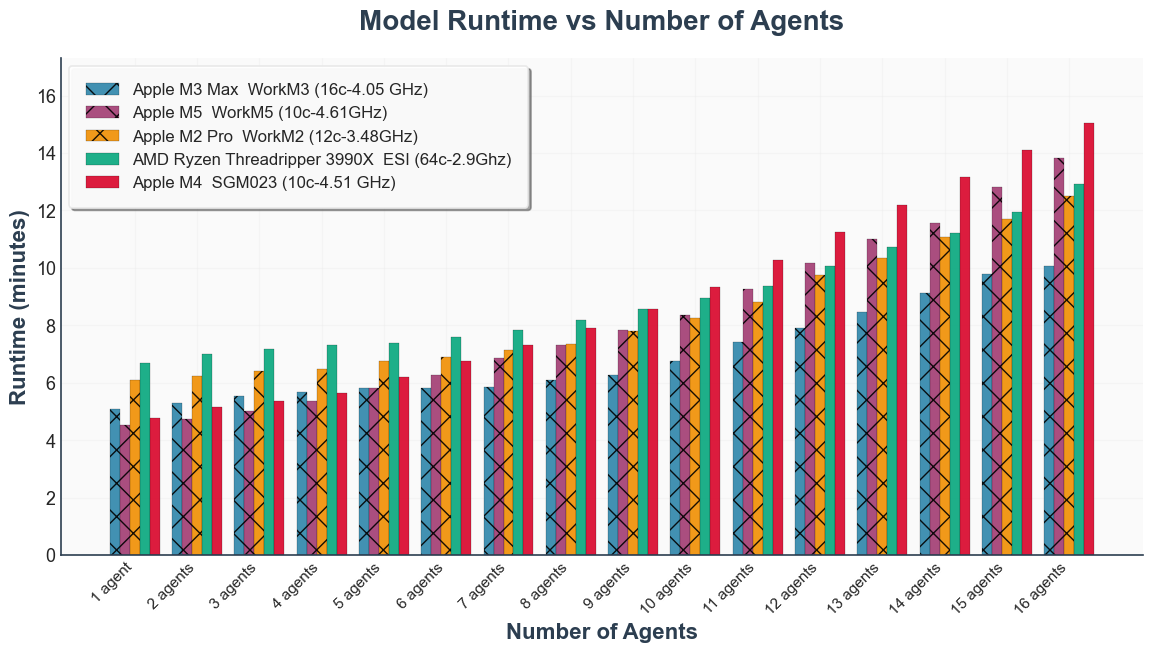

✅ Static chart saved: /Users/roh.sgm/Documents/GitHub_Projects/ARM_Benchmark_Public/ARM_Benchmark_Public/Scripts/Post-Proc/Outputs/runtime_barchart_M3Max_M2Pro_Threadripper_M5_M4_(2026-04-17_115557).png


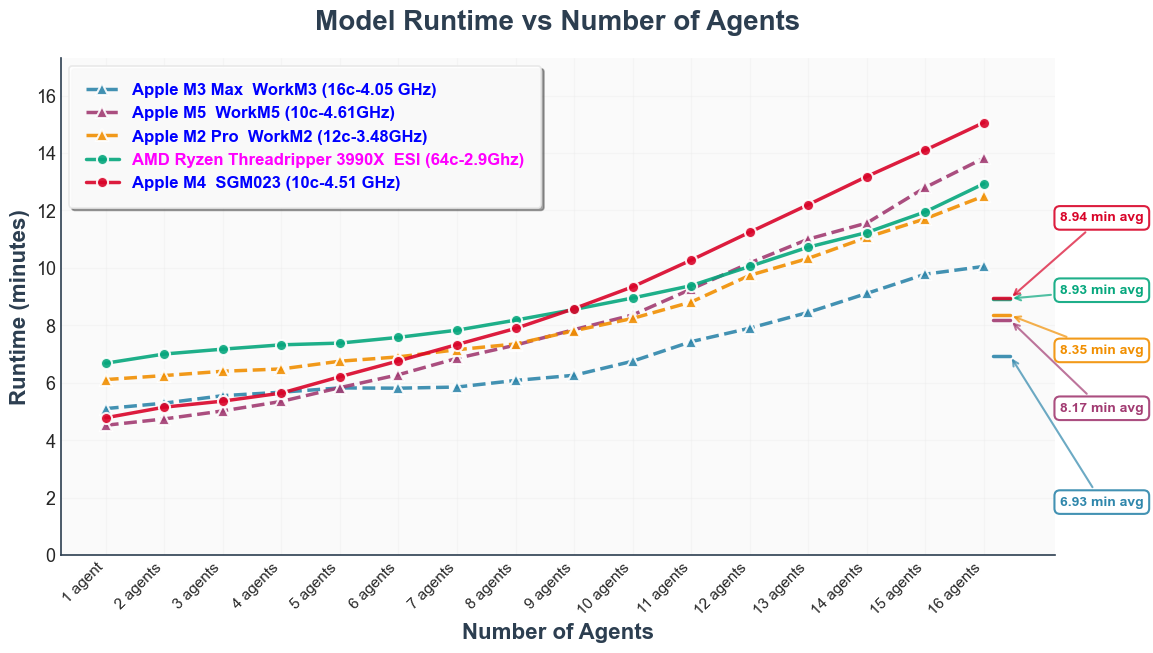

✅ Line plot saved: /Users/roh.sgm/Documents/GitHub_Projects/ARM_Benchmark_Public/ARM_Benchmark_Public/Scripts/Post-Proc/Outputs/runtime_lineplot_M3Max_M2Pro_Threadripper_M5_M4_(2026-04-17_115557).png

📊 Performance Comparison:
  1. Apple M3 Max  WorkM3 (16c-4.05 GHz)
     Avg: 6.93 min | Min: 5.10 min | Max: 10.05 min
  2. Apple M5  WorkM5 (10c-4.61GHz)
     Avg: 8.17 min | Min: 4.52 min | Max: 13.82 min
  3. Apple M2 Pro  WorkM2 (12c-3.48GHz)
     Avg: 8.35 min | Min: 6.11 min | Max: 12.50 min
  4. AMD Ryzen Threadripper 3990X  ESI (64c-2.9Ghz)
     Avg: 8.93 min | Min: 6.68 min | Max: 12.93 min
  5. Apple M4  SGM023 (10c-4.51 GHz)
     Avg: 8.94 min | Min: 4.78 min | Max: 15.06 min


In [4]:
def plot_runtime_barchart(data, metadata_rows, config_plot, extra_meta_data=None):
    """
    Create runtime performance bar chart comparing different computer configurations.
    
    Parameters:
    -----------
    data : DataFrame
        Runtime data with agent counts in rows and tests in columns
    metadata_rows : DataFrame
        First 3 rows containing test metadata (CPU, Model, Specs)
    config_plot : dict
        Configuration dictionary with options:
        - 'computer_filter': list - List of CPU names/keywords to include in comparison
                            Examples: ['M1', 'i7-10750H'], ['Ryzen', 'Xeon'], ['M1', 'M2', 'M3']
        - 'sort_by_performance': bool - Sort computers by average runtime (fastest to slowest) (default: False)
        - 'output_folder': str - path to save output images
        - 'create_animation': bool - whether to create GIF animation (default: False)
        - 'figsize': tuple - figure size (default: (12, 7))
        - 'dpi': int - resolution for saving (default: 300)
        - 'title': str - plot title (optional, uses default if None)
        - 'animation_fps': float - frames per second for animation (default: 1.4)
        - 'animation_interval': int - milliseconds between frames (default: 700)
    extra_meta_data : DataFrame, optional
        Additional metadata including Manufacturer information
    
    Returns:
    --------
    dict : Dictionary containing paths to saved files
    """
    
    current_time = datetime.now().strftime("%Y-%m-%d_%H%M%S")
    
    # Extract configuration with defaults
    computer_filter = config_plot.get('computer_filter', [])
    sort_by_performance = config_plot.get('sort_by_performance', False)
    output_folder = config_plot.get('output_folder', os.path.join(cwd, '..', 'Output'))
    create_animation = config_plot.get('create_animation', False)
    figsize = config_plot.get('figsize', (12, 7))
    dpi = config_plot.get('dpi', 300)
    custom_title = config_plot.get('title', None)
    animation_fps = config_plot.get('animation_fps', 1.4)
    animation_interval = config_plot.get('animation_interval', 700)
    label_rotation = config_plot.get('label_rotation', 90)  # Rotation for bar labels (0=horizontal, 90=vertical)
    plot_annotations = config_plot.get('plot_annotations', True)  # Whether to add value labels on bars
    
    # Create output directory
    os.makedirs(output_folder, exist_ok=True)
    
    if not computer_filter:
        print("⚠️ No computers specified in filter. Please provide a list of CPU names.")
        return None
    
    # Find matching columns in data based on computer_filter
    # Preserve the order specified in computer_filter list
    selected_tests = []
    selected_labels = []
    selected_data = []
    
    # Loop through filter keywords to preserve their order
    for filter_keyword in computer_filter:
        # Search for matching columns for this filter keyword
        for col_idx in range(1, len(metadata_rows.columns)):
            cpu = str(metadata_rows.iloc[0, col_idx])
            model = str(metadata_rows.iloc[1, col_idx])
            specs = str(metadata_rows.iloc[2, col_idx])
            
            # Check if this column matches the current filter keyword
            if filter_keyword.lower() in cpu.lower() or filter_keyword.lower() in model.lower():
                # Skip if already selected (avoid duplicates)
                if col_idx in selected_tests:
                    continue
                
                # Get manufacturer from extra_meta_data if available
                manufacturer = ''
                if extra_meta_data is not None and 'Manufacturer' in extra_meta_data.columns:
                    test_idx = col_idx - 1
                    if test_idx < len(extra_meta_data):
                        mfr = extra_meta_data.iloc[test_idx]['Manufacturer']
                        if pd.notna(mfr) and str(mfr).strip() and str(mfr).lower() != 'nan':
                            manufacturer = f"{str(mfr).strip()} "
                
                # Create label
                label = f"{manufacturer}{cpu} {model} {specs}"
                
                # Get runtime data (up to 16 agents)
                n_agents = min(data.shape[0], 16)
                runtime_data = data.iloc[:n_agents, col_idx].values
                
                # Convert to numeric
                numeric_data = []
                for val in runtime_data:
                    try:
                        if pd.isna(val):
                            numeric_data.append(np.nan)
                        else:
                            numeric_data.append(float(val))
                    except (ValueError, TypeError):
                        numeric_data.append(np.nan)
                
                selected_tests.append(col_idx)
                selected_labels.append(label)
                selected_data.append(np.array(numeric_data))
                break  # Found a match for this filter keyword, move to next filter
    
    if len(selected_data) == 0:
        print(f"⚠️ No matching computers found for filters: {computer_filter}")
        return None
    # Sort by performance if requested (fastest to slowest based on average runtime)
    if sort_by_performance:
        # Calculate average runtime for each computer
        avg_runtimes = [np.nanmean(data_array) for data_array in selected_data]
        
        # Sort all three lists together by average runtime (ascending = fastest first)
        sorted_indices = sorted(range(len(avg_runtimes)), key=lambda i: avg_runtimes[i])
        selected_tests = [selected_tests[i] for i in sorted_indices]
        selected_labels = [selected_labels[i] for i in sorted_indices]
        selected_data = [selected_data[i] for i in sorted_indices]
        
        print("🏆 Computers sorted by performance (fastest to slowest)")
    
    print(f"🖥️ Found {len(selected_data)} matching configurations:")
    for label in selected_labels:
        print(f"   - {label}")
    
    # ----- Modern styling configuration -----
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Roboto', 'Arial', 'Helvetica', 'DejaVu Sans'],
        'font.size': 12,
        'axes.titlesize': 16,
        'axes.labelsize': 14,
        'xtick.labelsize': 12,
        'ytick.labelsize': 13,
        'legend.fontsize': 12,
        'figure.titlesize': 20,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'axes.linewidth': 1.2,
        'grid.alpha': 0.3,
        'grid.linewidth': 0.8,
    })
    
    # Modern color palette (cycle through if more than 2 computers)
    color_palette = ['#2E86AB', '#A23B72', '#F18F01', '#06A77D', '#D90429', '#6A4C93']
    colors = {
        'grid': '#E8E8E8',
        'text': '#2C3E50',
        'bg': '#FAFAFA'
    }
    
    # Assign colors to each selected computer
    computer_colors = [color_palette[i % len(color_palette)] for i in range(len(selected_data))]
    
    # Agent labels
    n_agents = len(selected_data[0])
    agents = [f"{i} agent{'s' if i > 1 else ''}" for i in range(1, n_agents + 1)]
    x = np.arange(len(agents))
    
    # Calculate bar width based on number of computers
    total_width = 0.8
    width = total_width / len(selected_data)
    
    # Helper functions
    def add_labels(ax, rects, color='white', rotation=0):
        """Add value labels on bars with better styling"""
        for r in rects:
            height = r.get_height()
            if not np.isnan(height):
                ax.annotate(f"{height:.1f}",
                           xy=(r.get_x() + r.get_width() / 2, height),
                           xytext=(0, 4), textcoords="offset points",
                           ha='center', va='bottom', 
                           fontsize=10, fontweight='bold', color=color,
                           rotation=rotation)
    
    def setup_axes(ax, x_range=None):
        """Setup axes with modern styling"""
        if x_range is None:
            x_range = x
            agents_range = agents
        else:
            agents_range = agents[:len(x_range)]
        
        title = custom_title if custom_title else "Model Runtime vs Number of Agents"
        ax.set_title(title, 
                    fontsize=20, fontweight='bold', color=colors['text'], pad=20)
        ax.set_ylabel("Runtime (minutes)", 
                     fontsize=16, fontweight='bold', color=colors['text'])
        ax.set_xlabel("Number of Agents", 
                     fontsize=16, fontweight='bold', color=colors['text'])
        
        ax.set_xticks(x_range)
        ax.set_xticklabels(agents_range, rotation=45, ha="right", fontsize=11)
        
        # Set y-limit based on max value across all datasets
        max_val = max([np.nanmax(d) for d in selected_data])
        ax.set_ylim(0, max_val * 1.15)
        
        # Modern grid styling
        ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.8, color=colors['grid'])
        ax.set_axisbelow(True)
        
        # Remove top and right spines
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_color(colors['text'])
        ax.spines['bottom'].set_color(colors['text'])
    
    output_paths = {}
    
    # ----- Create static version -----
    fig_static, ax_static = plt.subplots(figsize=figsize, facecolor='white')
    fig_static.patch.set_facecolor('white')
    ax_static.set_facecolor(colors['bg'])
    
    setup_axes(ax_static)
    
    # Create bars for each computer
    bars_list = []
    for i, (data_array, label, color) in enumerate(zip(selected_data, selected_labels, computer_colors)):
        offset = (i - len(selected_data)/2 + 0.5) * width
        # Add hatch pattern for computers with 'Work' in their label
        hatch_pattern = 'x' if 'Work' in label else None
        bars = ax_static.bar(x + offset, data_array, width, 
                            label=label, color=color, 
                            alpha=0.9, edgecolor='k', linewidth=0.15,
                            hatch=hatch_pattern)
        bars_list.append(bars)
        if plot_annotations is not False:
            add_labels(ax_static, bars, color=colors['text'], rotation=label_rotation)
    
    # Modern legend for static version
    legend = ax_static.legend(loc="upper left", frameon=True, fancybox=True, 
                             shadow=True, framealpha=0.95, facecolor='white',
                             edgecolor=colors['grid'], borderpad=1)
    legend.get_frame().set_linewidth(1.2)
    
    # Save static version
    filter_text = '_'.join([f.replace(' ', '').replace('-', '') for f in computer_filter])
    png_path = os.path.join(output_folder, f"runtime_barchart_{filter_text}_({current_time}).png")
    fig_static.tight_layout(pad=2.0)
    fig_static.savefig(png_path, dpi=dpi, bbox_inches='tight', facecolor='white', 
                      edgecolor='none', transparent=False)
    plt.show()
    
    output_paths['static'] = png_path
    print(f"✅ Static chart saved: {png_path}")
    
    # ----- Create line plot version -----
    fig_line, ax_line = plt.subplots(figsize=figsize, facecolor='white')
    fig_line.patch.set_facecolor('white')
    ax_line.set_facecolor(colors['bg'])
    
    # Setup axes with same styling
    title = custom_title if custom_title else "Model Runtime vs Number of Agents"
    ax_line.set_title(title, 
                fontsize=20, fontweight='bold', color=colors['text'], pad=20)
    ax_line.set_ylabel("Runtime (minutes)", 
                 fontsize=16, fontweight='bold', color=colors['text'])
    ax_line.set_xlabel("Number of Agents", 
                 fontsize=16, fontweight='bold', color=colors['text'])
    
    ax_line.set_xticks(x)
    ax_line.set_xticklabels(agents, rotation=45, ha="right", fontsize=11)
    
    # Set y-limit based on max value across all datasets
    max_val = max([np.nanmax(d) for d in selected_data])
    ax_line.set_ylim(0, max_val * 1.15)
    
    # Modern grid styling
    ax_line.grid(True, alpha=0.3, linestyle='-', linewidth=0.8, color=colors['grid'])
    ax_line.set_axisbelow(True)
    
    # Remove top and right spines
    ax_line.spines['top'].set_visible(False)
    ax_line.spines['right'].set_visible(False)
    ax_line.spines['left'].set_color(colors['text'])
    ax_line.spines['bottom'].set_color(colors['text'])
    
    # Plot lines with circle markers for each computer
    for i, (data_array, label, color) in enumerate(zip(selected_data, selected_labels, computer_colors)):
        # Determine line style and marker based on 'Work' in label
        linestyle = '--' if 'Work' in label else '-'
        marker = '^' if 'Work' in label else 'o'  # Triangle for Work, circle for others
        linewidth = 2.5
        
        ax_line.plot(x, data_array, 
                    marker=marker, 
                    markersize=8,
                    linestyle=linestyle,
                    linewidth=linewidth,
                    color=color, 
                    label=label,
                    alpha=0.9,
                    markeredgecolor='white',
                    markeredgewidth=1.5)
    
    # Calculate mean values for each computer and sort by mean (lowest to highest)
    mean_data = [(np.nanmean(data_array), label, color, data_array) 
                 for data_array, label, color in zip(selected_data, selected_labels, computer_colors)]
    mean_data_sorted = sorted(mean_data, key=lambda x: x[0])
    
    # Add mean annotations with horizontal lines and straight arrows
    last_agent_x = x[-1]  # x position of 16th agent (last data point)
    horizontal_line_length = 0.3  # Length of the horizontal line marker
    horizontal_line_x_start = last_agent_x + 0.15
    
    # Calculate label positions to avoid overlap
    y_range = max_val * 1.15
    label_x = last_agent_x + 1.3  # Position to the right of plot area
    
    # Smart label positioning to avoid overlap with better vertical distribution
    mean_values = [m[0] for m in mean_data_sorted]
    n_computers = len(mean_data_sorted)
    
    # Calculate optimal label positions with intelligent spacing
    label_positions = []
    
    if n_computers == 1:
        # Single label - place at mean value
        label_positions = [mean_values[0]]
    elif n_computers == 2:
        # Two labels - one low, one high
        label_positions = [
            max(y_range * 0.05, min(mean_values[0] * 0.4, y_range * 0.15)),  # Low
            min(mean_values[-1] * 1.3, y_range * 0.90)  # High
        ]
    else:
        # Multiple labels - distribute across available space
        # Place first label low
        first_label_y = max(y_range * 0.04, min(mean_values[0] * 0.3, y_range * 0.10))
        
        # Place last label high
        last_label_y = min(mean_values[-1] * 1.3, y_range * 0.88)
        
        # Ensure minimum separation
        if last_label_y - first_label_y < y_range * 0.3:
            last_label_y = first_label_y + y_range * 0.3
        
        # Distribute middle labels evenly between first and last
        label_positions = [first_label_y]
        
        if n_computers > 2:
            # Calculate spacing for middle labels
            available_space = last_label_y - first_label_y
            spacing = available_space / (n_computers - 1)
            
            for idx in range(1, n_computers - 1):
                # Interpolate position between first and last
                label_y = first_label_y + (spacing * idx)
                
                # Optionally adjust based on mean value if it's close to natural position
                mean_influence = 0.2  # How much the mean value influences position (0-1)
                natural_y = mean_values[idx]
                
                # Blend interpolated position with mean-based position
                label_y = label_y * (1 - mean_influence) + natural_y * mean_influence
                
                # Ensure it's between previous and next positions
                min_y = label_positions[-1] + y_range * 0.05
                max_y = last_label_y - y_range * 0.05 * (n_computers - idx - 1)
                label_y = max(min_y, min(label_y, max_y))
                
                label_positions.append(label_y)
        
        label_positions.append(last_label_y)
    
    # Ensure all positions are within bounds
    label_positions = [max(y_range * 0.03, min(y, y_range * 0.97)) for y in label_positions]
    
    # Draw annotations with calculated positions
    for idx, ((mean_val, label, color, data_array), label_y) in enumerate(zip(mean_data_sorted, label_positions)):
        # Draw small horizontal line at the mean value height
        ax_line.plot([horizontal_line_x_start, horizontal_line_x_start + horizontal_line_length], 
                    [mean_val, mean_val], 
                    color=color, linewidth=2.5, alpha=0.9, zorder=10)
        
        # Create annotation with straight arrow
        ax_line.annotate(f'{mean_val:.2f} min avg', 
                        xy=(horizontal_line_x_start + horizontal_line_length, mean_val),  # Arrow points to end of horizontal line
                        xytext=(label_x, label_y),  # Label position
                        fontsize=10, 
                        fontweight='bold',
                        color=color,
                        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor=color, linewidth=1.5, alpha=0.9),
                        arrowprops=dict(arrowstyle='->', color=color, lw=1.5, alpha=0.7),
                        zorder=11)
    
    # Modern legend for line plot
    legend = ax_line.legend(loc="upper left", frameon=True, fancybox=True, 
                         shadow=True, framealpha=0.95, facecolor='white',
                         edgecolor=colors['grid'], borderpad=1)
    legend.get_frame().set_linewidth(1.2)
    
    # Color legend labels based on manufacturer (consistent with heatmap)
    for legend_text, label in zip(legend.get_texts(), selected_labels):
        if 'Apple' in label or 'apple' in label:
            legend_text.set_color('blue')
            legend_text.set_weight('bold')
        elif 'AMD' in label or 'amd' in label:
            legend_text.set_color('magenta')
            legend_text.set_weight('bold')
    
    # Save line plot version
    line_path = os.path.join(output_folder, f"runtime_lineplot_{filter_text}_({current_time}).png")
    fig_line.tight_layout(pad=2.0)
    fig_line.savefig(line_path, dpi=dpi, bbox_inches='tight', facecolor='white', 
                  edgecolor='none', transparent=False)
    plt.show()
    
    output_paths['lineplot'] = line_path
    print(f"✅ Line plot saved: {line_path}")
    
    plt.close(fig_line)
    
    # ----- Create animation if requested -----
    if create_animation:
        fig_anim, ax_anim = plt.subplots(figsize=figsize, facecolor='white')
        fig_anim.patch.set_facecolor('white')
        ax_anim.set_facecolor(colors['bg'])
        
        def init():
            """Initialize animation"""
            ax_anim.clear()
            setup_axes(ax_anim)
            return []
        
        def animate(k):
            """Animation function with modern styling"""
            ax_anim.clear()
            
            # Setup current frame
            xi = x[:k+1]
            setup_axes(ax_anim, xi)
            
            # Create bars for each computer
            all_bars = []
            for i, (data_array, label, color) in enumerate(zip(selected_data, selected_labels, computer_colors)):
                offset = (i - len(selected_data)/2 + 0.5) * width
                # Add hatch pattern for computers with 'Work' in their label
                hatch_pattern = 'x' if 'Work' in label else None
                alpha = 0.15 if 'Work' in label else 1.0
                bars = ax_anim.bar(xi + offset, data_array[:k+1], width, 
                                  label=label, color=color, 
                                  alpha=alpha, edgecolor='lightgrey', linewidth=0.5,
                                  hatch=hatch_pattern)
                all_bars.extend(list(bars))
                
                # Add labels
                for r in bars:
                    height = r.get_height()
                    if not np.isnan(height):
                        ax_anim.annotate(f"{height:.1f}",
                                       xy=(r.get_x() + r.get_width() / 2, height),
                                       xytext=(0, 4), textcoords="offset points",
                                       fontsize=10, fontweight='bold', color=colors['text'],
                                       rotation=label_rotation)
            
            # Modern legend styling
            legend = ax_anim.legend(loc="upper left", frameon=True, fancybox=True, 
                                   shadow=True, framealpha=0.95, facecolor='white',
                                   edgecolor=colors['grid'], borderpad=1)
            legend.get_frame().set_linewidth(1.2)
            
            return all_bars
        
        # Create animation
        anim = FuncAnimation(fig_anim, animate, frames=len(agents), init_func=init, 
                            interval=animation_interval, blit=False, repeat=False)
        
        # Save as GIF
        gif_path = os.path.join(output_folder, f"runtime_barchart_{filter_text}_animation_({current_time}).gif")
        anim.save(gif_path, writer=PillowWriter(fps=animation_fps), dpi=150)
        
        output_paths['animation'] = gif_path
        print(f"✅ Animation saved: {gif_path}")
        
        plt.close(fig_anim)
    
    plt.close(fig_static)
    
    # Print summary statistics
    print(f"\n📊 Performance Comparison:")
    for i, (label, data_array) in enumerate(zip(selected_labels, selected_data)):
        avg_time = np.nanmean(data_array)
        min_time = np.nanmin(data_array)
        max_time = np.nanmax(data_array)
        print(f"  {i+1}. {label}")
        print(f"     Avg: {avg_time:.2f} min | Min: {min_time:.2f} min | Max: {max_time:.2f} min")
    
    return output_paths


# ===============================================
# Example Usage
# ===============================================

config_barchart = {
    #'computer_filter': ['M1', 'i7-10750H'],  # List of CPU keywords to compare
    'computer_filter': ['M3 Max', 'M2 Pro', 'Threadripper', 'M5','M4'],  # List of CPU keywords to compare
    'sort_by_performance': True,  # Set to True to sort by average runtime (fastest to slowest)
    'output_folder': os.path.join(cwd, 'Outputs'),
    'plot_annotations': False,
    'create_animation': False,  # Set to True to create GIF animation
    'figsize': (12, 7),
    'dpi': 300,
    'label_rotation': 90,       # Rotation angle for bar labels (0=horizontal, 90=vertical)
    'animation_fps': 1.4,       # Frames per second for animation
    'animation_interval': 700,  # Milliseconds between frames
}


output_files = plot_runtime_barchart(data, metadata_rows, config_barchart, extra_meta_data)

# Create the bar chart
# Create the bar chartoutput_files = plot_runtime_barchart(data, metadata_rows, config_barchart, extra_meta_data)

## x86 vs ARM Native Comparison Plot (1-to-1 per Mac)

🖥️  Machines with paired x86 / ARM data: ['WorkM5']


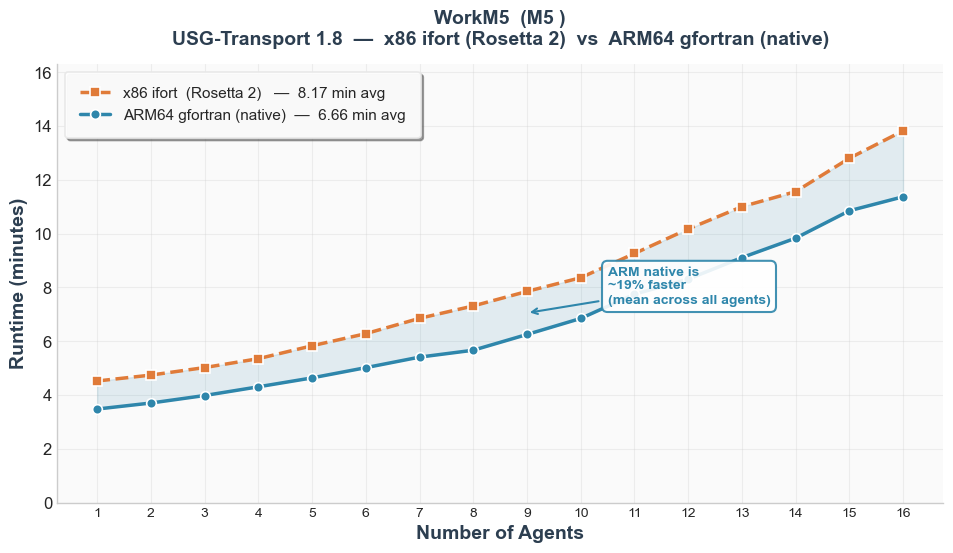

✅ Saved: /Users/roh.sgm/Documents/GitHub_Projects/ARM_Benchmark_Public/ARM_Benchmark_Public/Scripts/Post-Proc/Outputs/exe_comparison_WorkM5_(2026-04-17_115558).png
   x86 mean: 8.17 min  |  ARM mean: 6.66 min  |  Speedup: 1.23×  (18.5% faster)


In [5]:
def plot_exe_comparison(data, extra_meta_data, config):
    """
    1-to-1 comparison of x86 (Rosetta 2) vs ARM native runtimes for each Mac
    computer that has both exe types in the dataset.

    Requires 'Exe Architecture' column in Authors sheet.

    Parameters
    ----------
    data : DataFrame
        Runtime data (Agent Number in col 0, Test1..TestN in remaining cols).
    extra_meta_data : DataFrame
        Authors sheet — must contain '#', 'Computer', 'Exe Architecture' columns.
    config : dict
        Keys:
          'computer_filter' : list[str] — machine names to include (e.g. ['WorkM5']).
                              Empty list = all machines with paired data.
          'output_folder'   : str — where to save PNG files.
          'figsize'         : tuple  (default (10, 6))
          'dpi'             : int    (default 300)
          'show_speedup'    : bool   show shaded speedup region + annotation (default True)
    """
    from datetime import datetime as _dt

    current_time = _dt.now().strftime('%Y-%m-%d_%H%M%S')
    output_folder = config.get('output_folder', os.path.join(cwd, 'Outputs'))
    figsize       = config.get('figsize', (10, 6))
    dpi           = config.get('dpi', 300)
    show_speedup  = config.get('show_speedup', True)
    computer_filter = config.get('computer_filter', [])
    os.makedirs(output_folder, exist_ok=True)

    # ── Identify paired tests ─────────────────────────────────────────────────
    if 'Exe Architecture' not in extra_meta_data.columns:
        print('⚠️  "Exe Architecture" column not found in Authors sheet.')
        print('   Please update ByscayneMode_Benchmarks.xlsx and re-run the data import cell.')
        return

    meta = extra_meta_data.copy()
    # Normalise exe-arch labels into two buckets
    meta['_exe_type'] = meta['Exe Architecture'].apply(
        lambda v: 'arm' if str(v).lower().startswith('arm') else 'x86'
    )

    # Find computers that have ≥1 x86 test AND ≥1 ARM test
    paired_computers = []
    for computer, grp in meta.groupby('Computer'):
        has_x86 = (grp['_exe_type'] == 'x86').any()
        has_arm = (grp['_exe_type'] == 'arm').any()
        if has_x86 and has_arm:
            paired_computers.append(computer)

    if computer_filter:
        paired_computers = [c for c in paired_computers
                            if any(f.lower() in c.lower() for f in computer_filter)]

    if not paired_computers:
        print('⚠️  No computers found with both x86 and ARM native results.')
        return

    print(f'🖥️  Machines with paired x86 / ARM data: {paired_computers}')

    # ── Styling ───────────────────────────────────────────────────────────────
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
        'font.size': 12,
        'axes.titlesize': 16,
        'axes.labelsize': 14,
        'xtick.labelsize': 11,
        'ytick.labelsize': 12,
        'legend.fontsize': 11,
        'axes.spines.top': False,
        'axes.spines.right': False,
    })

    color_x86 = '#E07B39'   # warm orange — x86 / Rosetta 2
    color_arm = '#2E86AB'   # cool blue  — ARM native
    colors_text = '#2C3E50'

    saved_paths = []

    for computer in paired_computers:
        grp = meta[meta['Computer'] == computer]
        x86_rows = grp[grp['_exe_type'] == 'x86']
        arm_rows = grp[grp['_exe_type'] == 'arm']

        # Use the first matching test for each type
        test_x86 = x86_rows.iloc[0]['#']
        test_arm = arm_rows.iloc[0]['#']

        cpu_label = grp.iloc[0]['CPU Type'] if 'CPU Type' in grp.columns else computer

        # Pull runtime arrays from data (column name matches test ID)
        if test_x86 not in data.columns or test_arm not in data.columns:
            print(f'  ⚠️  Runtime data not found for {computer} ({test_x86}, {test_arm}) — skipping.')
            continue

        rt_x86 = pd.to_numeric(data[test_x86], errors='coerce').values[:16]
        rt_arm = pd.to_numeric(data[test_arm], errors='coerce').values[:16]
        n = min(len(rt_x86), len(rt_arm), 16)
        agents = np.arange(1, n + 1)
        x_pos  = np.arange(n)

        # ── Figure ────────────────────────────────────────────────────────────
        fig, ax = plt.subplots(figsize=figsize, facecolor='white')
        fig.patch.set_facecolor('white')
        ax.set_facecolor('#FAFAFA')

        # Shaded region between curves
        if show_speedup:
            ax.fill_between(x_pos, rt_arm[:n], rt_x86[:n],
                            alpha=0.12, color=color_arm, label='_nolegend_')

        # x86 line
        ax.plot(x_pos, rt_x86[:n],
                color=color_x86, linewidth=2.5, linestyle='--',
                marker='s', markersize=7,
                markeredgecolor='white', markeredgewidth=1.2,
                label=f'x86 ifort  (Rosetta 2)   —  {np.nanmean(rt_x86[:n]):.2f} min avg')

        # ARM line
        ax.plot(x_pos, rt_arm[:n],
                color=color_arm, linewidth=2.5, linestyle='-',
                marker='o', markersize=7,
                markeredgecolor='white', markeredgewidth=1.2,
                label=f'ARM64 gfortran (native)  —  {np.nanmean(rt_arm[:n]):.2f} min avg')

        # Speedup annotation at midpoint
        if show_speedup:
            mid = n // 2
            speedup_pct = (rt_x86[mid] - rt_arm[mid]) / rt_x86[mid] * 100
            mean_speedup = (np.nanmean(rt_x86[:n]) - np.nanmean(rt_arm[:n])) / np.nanmean(rt_x86[:n]) * 100
            ax.annotate(
                f'ARM native is\n~{mean_speedup:.0f}% faster\n(mean across all agents)',
                xy=(mid, (rt_x86[mid] + rt_arm[mid]) / 2),
                xytext=(mid + 1.5, (rt_x86[mid] + rt_arm[mid]) / 2 * 1.05),
                fontsize=10, fontweight='bold', color=color_arm,
                bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                          edgecolor=color_arm, linewidth=1.5, alpha=0.9),
                arrowprops=dict(arrowstyle='->', color=color_arm, lw=1.5)
            )

        # Axes
        ax.set_xticks(x_pos)
        ax.set_xticklabels([f'{i}' for i in agents], fontsize=10)
        ax.set_xlabel('Number of Agents', fontsize=14, fontweight='bold', color=colors_text)
        ax.set_ylabel('Runtime (minutes)', fontsize=14, fontweight='bold', color=colors_text)
        ax.set_title(
            f'{computer}  ({cpu_label})\n'
            f'USG-Transport 1.8  —  x86 ifort (Rosetta 2)  vs  ARM64 gfortran (native)',
            fontsize=14, fontweight='bold', color=colors_text, pad=14
        )
        ax.set_ylim(0, max(np.nanmax(rt_x86[:n]), np.nanmax(rt_arm[:n])) * 1.18)
        ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.8)
        ax.set_axisbelow(True)

        legend = ax.legend(loc='upper left', frameon=True, fancybox=True,
                           shadow=True, framealpha=0.95, facecolor='white',
                           edgecolor='#E8E8E8', borderpad=1)
        legend.get_frame().set_linewidth(1.2)

        fig.tight_layout(pad=2.0)
        safe_name = computer.replace(' ', '_')
        out_path = os.path.join(
            output_folder,
            f'exe_comparison_{safe_name}_({current_time}).png'
        )
        fig.savefig(out_path, dpi=dpi, bbox_inches='tight',
                    facecolor='white', edgecolor='none')
        plt.show()
        saved_paths.append(out_path)
        print(f'✅ Saved: {out_path}')

        mean_x86 = np.nanmean(rt_x86[:n])
        mean_arm = np.nanmean(rt_arm[:n])
        print(f'   x86 mean: {mean_x86:.2f} min  |  ARM mean: {mean_arm:.2f} min  '
              f'|  Speedup: {mean_x86/mean_arm:.2f}×  ({(mean_x86-mean_arm)/mean_x86*100:.1f}% faster)')
        plt.close(fig)

    return saved_paths


# ── Example usage ─────────────────────────────────────────────────────────────
config_exe_comparison = {
    'computer_filter': [],          # [] = all machines with paired data; or e.g. ['WorkM5']
    'output_folder': os.path.join(cwd, 'Outputs'),
    'figsize': (10, 6),
    'dpi': 300,
    'show_speedup': True,
}

saved = plot_exe_comparison(data, extra_meta_data, config_exe_comparison)
